<h1>To what extent do changes in net migration explain variations in median house prices across Australia's states and territories?</h1>

<h2>Overview</h2>
<span class="body-text">
This project examines the relationship between <strong>net overseas migration</strong> and
<strong>median house prices</strong> across Australia's states and territories.

Using housing, population, and migration data from the Australian Bureau of Statistics (ABS),
the analysis explores whether changes in net migration are associated with variations in median
house prices over time. The results aim to contribute to policy discussions on housing
affordability and population growth by clarifying the extent to which migration alone explains
housing price variation, and by highlighting the importance of additional structural and
economic factors.
</span>

<h2>Objectives</h2>
<ol class="body-text">
<li>Identify and assess the availability and structure of relevant housing, population, and migration data.</li>
<li>Calculate net migration rates and median house prices for each Australian state and territory.</li>
<li>Examine temporal trends and explain notable variations by reference to major real-world events, such as the COVID-19 pandemic.</li>
<li>Visualise the relationship between net migration and median house prices across states and territories.</li>
<li>Quantify the statistical correlation between net migration rates and changes in median house prices using Pearson's correlation and corresponding hypothesis tests.</li>
</ol>
<h2>Hypotheses</h2>
<ul class="body-text">
<li><strong>Null hypothesis (H<sub>0</sub>):</strong> There is no statistically significant linear relationship between net overseas migration rates and changes in median house prices across Australia's states and territories.</li>
<li><strong>Alternative hypothesis (H<sub>1</sub>):</strong> There is a statistically significant linear relationship between net overseas migration rates and changes in median house prices across Australia's states and territories.</li>
</ul>
<h2>Datasets Used</h2>
<h4>Source: Australian Bureau of Statistics (ABS)</h4>
<ul class="body-text" style="list-style-type: square">
<li>Net Overseas Migration</li>
<li>Estimated Resident Population (States and Territories)</li>
<li>Median Price and Number of Transfers (Capital City and Rest of State)</li>
</ul>

<strong class="body-text">All data cleaning and relevant preprocessing steps were conducted in a separate notebook for the datasets that required it. This notebook focuses on exploratory data analysis and analysing correlations using statistical techniques.</strong>
<h4>Data Preparation Summary</h4>
<ul class="body-text" style="list-style-type: square">
<li>Filtered data to remove header cells that contained metadata</li>
<li>Removed all columns that did not contain data</li>
<li>Changed the indices and columns of the datasets to what is required for our analysis.</li>
</ul>

In [41]:
from IPython.display import HTML
# SET UP STANDARDISED FORMATTING
display(HTML("""
<style>
.body-text {
    font-size: 18px;
}
</style>
"""))

<h2>Loading all datasets</h2>

In [42]:
import pandas as pd

migration_data = pd.read_csv('../data/migration_data.csv')
migration_data = migration_data.iloc[:, 1:]
print(migration_data.shape)
migration_data.head()

(300, 5)


,Arrival,Departure,Total,Year,State-Territory
0,75020,-39100,35920,2006,New South Wales
1,51670,-23810,27860,2006,Victoria
2,41240,-21250,19980,2006,Queensland
3,11820,-4640,7180,2006,South Australia
4,26430,-11520,14910,2006,Western Australia


<h4>Modifying the migration data</h4>
<span class="body-text">Our migration data needs a little preprocessing to get it into a DataFrame that can easily be operated with for analysis. <strong>This dataset did not require any extensive preprocessing unlike the other two.</strong></span>

In [43]:
migration_data_reshaped = migration_data.groupby(['Year', 'State-Territory'])['Total'].mean()
cols_to_drop = ['Christmas Island', 'Cocos (Keeling) Islands', 'Jervis Bay', 'Norfolk Island', 'Not Stated', 'Other Territories', 'Total']
migration_data_reshaped = migration_data_reshaped.drop(labels=cols_to_drop, level='State-Territory')
migration_data_reshaped = migration_data_reshaped.unstack(level=1)
migration_data_reshaped.index = pd.to_datetime(migration_data_reshaped.index, format='%Y')
migration_data_reshaped['Australia'] = migration_data_reshaped.sum(axis=1)
migration_data_reshaped.head()

State-Territory,Australian Capital Territory,New South Wales,Northern Territory,Queensland,South Australia,Tasmania,Victoria,Western Australia,Australia
Year,,,,,,,,,
2006-01-01,670.0,35920.0,260.0,19980.0,7180.0,800.0,27860.0,14910.0,107580.0
2007-01-01,1880.0,76900.0,1380.0,47680.0,13830.0,1470.0,66470.0,34430.0,244040.0
2008-01-01,3330.0,96430.0,1970.0,62840.0,17620.0,2090.0,83230.0,48190.0,315700.0
2009-01-01,3670.0,70160.0,1690.0,47330.0,17170.0,1930.0,72090.0,32840.0,246880.0
2010-01-01,2000.0,50040.0,1090.0,31670.0,10890.0,1230.0,43210.0,31900.0,172030.0


<h4>Fetching population data</h4>

<span style="font-size: 18px">We need population data in order to calculate per capital migration, which as we will justify later, is a more accurate metric for migration across vastly different states compared to a raw migration figure. </span>

In [44]:
# calculate the net migration per 1000 residents before calculating percentage change
population_data = pd.read_csv('../data/population_data.csv')
population_data.index = population_data.pop('Quarter')
population_data.index = pd.to_datetime(population_data.index)
# store the national population in each year separately
print(population_data.shape)
print(population_data.index)
population_data.head()

(177, 9)
DatetimeIndex(['1981-06-01', '1981-09-01', '1981-12-01', '1982-03-01',
               '1982-06-01', '1982-09-01', '1982-12-01', '1983-03-01',
               '1983-06-01', '1983-09-01',
               ...
               '2023-03-01', '2023-06-01', '2023-09-01', '2023-12-01',
               '2024-03-01', '2024-06-01', '2024-09-01', '2024-12-01',
               '2025-03-01', '2025-06-01'],
              dtype='datetime64[ns]', name='Quarter', length=177, freq=None)


,New South Wales,Victoria,Queensland,South Australia,Western Australia,Tasmania,Northern Territory,Australian Capital Territory,Australia
Quarter,,,,,,,,,
1981-06-01,5234889,3946917,2345208,1318769,1300056,427224,122616,227581,14923260
1981-09-01,5249455,3957333,2367477,1321235,1311284,427925,125186,228782,14988677
1981-12-01,5266894,3968398,2387943,1325176,1320221,428283,127718,229484,15054117
1982-03-01,5286119,3980826,2406355,1328670,1329700,429445,129593,230990,15121698
1982-06-01,5303580,3992870,2424586,1331108,1338899,429845,130314,233045,15184247


<h4> Intermediate step: Synchronising time index</h4>

<span style="font-size: 18px">In order for our vectorized calculation of per capita migration to work, we need the time indices to be the same. Since the migration data only goes back to 2006, our population data must be restricted to 2006 at earliest.</span>

In [45]:
population_data = population_data.loc[population_data.index.year >= 2006]

# aggregate the data from a quarterly to a yearly frequency
population_data = population_data.groupby(population_data.index.year)[population_data.columns].nth(1)
population_data.head()

,New South Wales,Victoria,Queensland,South Australia,Western Australia,Tasmania,Northern Territory,Australian Capital Territory,Australia
Quarter,,,,,,,,,
2006-06-01,6742690,5061266,4007992,1552529,2050581,489302,209057,335170,20450966
2007-06-01,6834156,5153522,4111018,1570619,2106139,493262,213748,342644,20827622
2008-06-01,6943461,5256375,4219505,1588665,2171700,498568,219874,348368,21249199
2009-06-01,7053755,5371934,4328771,1608902,2240250,504353,226027,354785,21691653
2010-06-01,7144292,5461101,4404744,1627322,2290845,508847,229778,361766,22031750


<h2>Objective: Obtain a suitable metric for determining the rate of migration within different states/territories</h2>
<span style="font-size: 18px">We decided to look at net migration on a </strong>per capita basis</strong>, specifically looking at number of migrants per 1000 residents.
<h4> Our reasoning:</h4>
<ul style="font-size: 18px; list-style-type: square">
<li>Different states have <strong>different scales</strong> for the amount of migration that occurs due to their different populations.</li>
<li>For example, New South Wales will have a higher absolute value for net migration, but when calculating percentage change in net migration, its large volume of migrants yearly might dilute the signal.</li>
<li>On the other hand, the Northern Territory (NT) does not get as many migrants so even a small increase could warrant very large percentage increases.</li>
</ul>

<span style="font-size: 18px">Our aim was to account for size differences, precisely by using this officially endorsed metric for migration.</span>

<span style="font-size: 18px">
$$
\text{Net Overseas Migration Per 1000 Residents} = \frac{\text{Net Overseas Migration}}{\text{Population of State}}
$$
</span>

In [46]:
# the population and migration data have their column orders mismatched. this must be fixed
migration_data_reshaped = migration_data_reshaped[population_data.columns]
migration_per_capita = pd.DataFrame(migration_data_reshaped.values / population_data.values * 1000, index=migration_data_reshaped.index, columns=migration_data_reshaped.columns)
migration_per_capita.head()

State-Territory,New South Wales,Victoria,Queensland,South Australia,Western Australia,Tasmania,Northern Territory,Australian Capital Territory,Australia
Year,,,,,,,,,
2006-01-01,5.327251,5.504552,4.985040,4.624712,7.271110,1.634982,1.243680,1.998986,5.260387
2007-01-01,11.252304,12.897975,11.598101,8.805445,16.347449,2.980161,6.456201,5.486744,11.717132
2008-01-01,13.887887,15.834106,14.892742,11.091073,22.189989,4.192006,8.959677,9.558857,14.857031
2009-01-01,9.946475,13.419748,10.933819,10.671874,14.659078,3.826685,7.476983,10.344293,11.381336
2010-01-01,7.004193,7.912324,7.189975,6.691976,13.924993,2.417230,4.743709,5.528436,7.808277


<h4>Fetching dataset for median house prices and number of transfers</h4>
<span class="body-text">We retrieved our house prices data, which contains information about number of house transfers alongside it. The latter was useful for estimating median prices on a state and national level since we don't have this information directly available to us through any dataset.</span>

In [47]:
house_prices_and_transfers = pd.read_csv('../data/median_price_data.csv')
house_prices_and_transfers.index = pd.to_datetime(house_prices_and_transfers.pop('Quarter'))
house_prices_and_transfers.head()

,Median Price of Established House Transfers (Unstratified) ; Sydney ;,Median Price of Established House Transfers (Unstratified) ; Rest of NSW ;,Median Price of Established House Transfers (Unstratified) ; Melbourne ;,Median Price of Established House Transfers (Unstratified) ; Rest of Vic. ;,Median Price of Established House Transfers (Unstratified) ; Brisbane ;,Median Price of Established House Transfers (Unstratified) ; Rest of Qld. ;,Median Price of Established House Transfers (Unstratified) ; Adelaide ;,Median Price of Established House Transfers (Unstratified) ; Rest of SA ;,Median Price of Established House Transfers (Unstratified) ; Perth ;,Median Price of Established House Transfers (Unstratified) ; Rest of WA ;,...,Number of Attached Dwelling Transfers ; Rest of Qld. ;,Number of Attached Dwelling Transfers ; Adelaide ;,Number of Attached Dwelling Transfers ; Rest of SA ;,Number of Attached Dwelling Transfers ; Perth ;,Number of Attached Dwelling Transfers ; Rest of WA ;,Number of Attached Dwelling Transfers ; Hobart ;,Number of Attached Dwelling Transfers ; Rest of Tas. ;,Number of Attached Dwelling Transfers ; Darwin ;,Number of Attached Dwelling Transfers ; Rest of NT ;,Number of Attached Dwelling Transfers ; Canberra ;
Quarter,,,,,,,,,,,,,,,,,,,,,
2002-03-01,365.0,NaN,241.0,NaN,185.0,NaN,166.0,NaN,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-06-01,393.5,NaN,260.0,NaN,182.6,NaN,175.0,NaN,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-09-01,413.0,NaN,265.0,NaN,198.0,NaN,181.0,NaN,195.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-12-01,444.0,NaN,280.0,NaN,208.0,NaN,195.0,NaN,206.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-03-01,434.5,NaN,270.0,NaN,225.0,NaN,209.4,NaN,216.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h2>Key Limitations</h2>
<span style="font-size: 18px;">
<ul style="list-style-type: square; font-size: 18px; ">
<li> Since our migration data is only split by states, we will need to find a way to combine the percentage changes in the median price data for data within a capital city versus in the rest of the state the capital city belongs to. </li>
<li> Since regional parts of a state are not contributing equally to the capital city for a state's median price, we will need a **weighted average**. </li>
 <li> This is where the number of transfers of buildings comes in handy. The contribution of a region to the median price is related to how many house transfers are involved within it. </li>
</span>
</ul>
<span style="font-size: 18px;"> We will use two average formulas to get reasonable approximations of the median prices across each state given the limitations of our data. </span>

<h2>Justifications</h2>
<ul style="list-style-type: square; font-size: 18px;">
<li>Since we don't have access to pricing and transfer data from all residential building types, we need approximations.</li>
<li>We take a <strong>weighted average</strong> when calculating median price per region rather than a simple halfway average because we don't expect established houses and detached dwellings to contribute equally to an area's median house prices or number of transfers.</li>
<li>We also take a <strong>weighted average</strong> when calculating median price per state because we expect capital cities to contribute more in median pricing and number of transfers for a state than any other place within the state.</li>
</ul>
<span style="font-size: 18px;" > First step is to calculate the median price changes for each of the capital cities and then each of the regions outside the capital city (eg. rest of NSW, rest of VIC etc.). We will call these <strong>regions</strong>. </span>
<span style="font-size: 24px">
\begin{align}
P_r = \frac{n_{r, e} \times p_{r, e} + n_{r, d} \times p_{r, d}}{n_{r, e}+n_{r, d}}
\end{align}
</span>



<span style="font-size: 24px;"> Variables </span>

<table style="width: 90%; margin-left: auto; margin-right: auto; border-collapse: collapse; font-size: 16px;">
  <tr>
    <th style="padding: 10px; border: 1px solid #ccc; font-size: 18px;">Term</th>
    <th style="padding: 10px; border: 1px solid #ccc;">Meaning</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$P_i$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Median house price of region $r$ (which is a capital city or the greater region for a state).</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$p_{r, e}$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Median price of established houses in region $r$.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$p_{r, d}$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Median price of detached dwellings in region $r$.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$n_{r, e}$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Number of established house transfers in region $r$.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$n_{r, d}$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Number of detached dwelling transfers in region $r$.</td>
  </tr>
</table>


In [48]:
def split_data(data, skip_rows=0):
    """
    Splits the housing data into separate median prices and house transfer count DataFrames
    :param data:
    :param skip_rows:
    :return: 2-tuple (prices, transfer) containing two DataFrames
    """
    newData = data.copy()
    mask = ['Price' in col for col in data.columns]
    price = newData.loc[:, mask]
    transfer = newData.loc[:, [not entry for entry in mask]]
    return price.iloc[skip_rows:], transfer.iloc[skip_rows:]
def calculate_prices_per_region(prices_df, transfers_df):
    """
    Calculates the weighted median house price of a region (capital city/rest of state)
    :param prices_df: DataFrame containing the prices for established houses and detached dwellings in each region
    :param transfers_df: DataFrame containing the number of transfers of established houses and detached dwellings in each region
    :return: DataFrame containing the estimated median house price for each region
    """
    # first we calculate the numerator, which is the weighted average (dot product) of the house prices and number of transfers
    prices_type_1 = prices_df.iloc[:, :15]
    prices_type_2 = prices_df.iloc[:, 15:]
    transfers_type_1 = transfers_df.iloc[:, :15]
    transfers_type_2 = transfers_df.iloc[:, 15:]
    weighted_sum = prices_type_1.values * transfers_type_1.values + prices_type_2.values * transfers_type_2.values
    denominator = transfers_type_1.values + transfers_type_2.values
    column_tags = pd.Series(prices_df.columns.str.extract(r';\s*([^;]+)')[0].str.strip()).unique()
    # wrap data in a DataFrame
    return pd.DataFrame(weighted_sum / denominator, columns=column_tags, index=prices_df.index)
prices, transfers = split_data(house_prices_and_transfers, 6)
estimated_house_prices_by_region = calculate_prices_per_region(prices, transfers)
print(estimated_house_prices_by_region.shape)
estimated_house_prices_by_region.head()

(89, 15)


,Sydney,Rest of NSW,Melbourne,Rest of Vic.,Brisbane,Rest of Qld.,Adelaide,Rest of SA,Perth,Rest of WA,Hobart,Rest of Tas.,Darwin,Rest of NT,Canberra
Quarter,,,,,,,,,,,,,,,
2003-09-01,430.876855,246.013688,288.990998,174.319516,255.359542,208.802993,219.985590,141.989041,225.260158,156.773582,165.000000,125.485245,183.446977,176.682310,330.890244
2003-12-01,459.687687,254.141779,308.917050,183.358839,280.809134,215.443218,232.351775,152.463303,236.090967,160.521764,180.786641,136.886470,192.401198,179.681661,342.916860
2004-03-01,461.932099,265.698717,295.176313,188.023869,288.936353,233.235288,234.418043,156.725281,242.416230,173.269262,198.049131,154.684731,208.624324,197.643243,340.318681
2004-06-01,443.863991,269.140297,298.919878,192.405996,290.566858,242.902920,241.771758,158.039435,250.233094,174.342901,217.434126,155.129169,211.161688,193.750000,347.708333
2004-09-01,446.713720,272.672140,293.609732,192.595924,293.860747,251.017354,248.354309,164.990210,247.007512,181.684462,222.046714,159.408040,209.800103,211.102667,318.928344


<div style="background-color: #fff8e1; padding: 12px; border-left: 6px solid #ffb300; border-radius: 5px; font-size: 15px;">
<strong style="color: black; font-size: 20px">Steps Taken:</strong>
<ul style="list-style-type: none; padding-left: 0">
  <li>✅ <strong style="color: black">Separated</strong> the house data into median prices and transfers <strong style="color: black"> per region, per house type. </strong> </li>
  <li>✅ <strong style="color: black">Vectorized</strong> calculation of estimated median house price per region.</li>
  <li>✅ <strong style="color: black">Wrapped</strong> the resultant data into a labelled DataFrame for use in the next calculation step.</li>
</ul>
</div>

<h1 style="color: black;">Next Step: Calculate approximate Median House Price Per State</h1>
<span style="font-size: 18px;">This will be done using a similar formula to before.</span>

<span style="font-size: 18px">
\begin{align}
P_s = \frac{n_c \times p_c + n_r \times p_r}{n_c+n_r}
\end{align}
</span>

<span style="font-size: 24px;"> Variables </span>

<table style="width: 90%; margin-left: auto; margin-right: auto; border-collapse: collapse; font-size: 16px;">
  <tr>
    <th style="padding: 10px; border: 1px solid #ccc; font-size: 18px;">Term</th>
    <th style="padding: 10px; border: 1px solid #ccc;">Meaning</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$P_s$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Median house price of state $s$.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$p_c$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Estimated median price of houses in capital city.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$p_r$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Estimated median price of houses in rest of state.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$n_c$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Number of total house transfers in capital city.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$n_r$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Number of total house transfers in rest of state.</td>
  </tr>
</table>

In [49]:
# first sum up the number of established house transfers and number of detached dwelling transfers
summed_house_transfers = pd.DataFrame()
for i in range(15):
    summed_house_transfers[f'sum_{i+1}'] = transfers.iloc[:, i] + transfers.iloc[:, i + 15]
summed_house_transfers.columns = estimated_house_prices_by_region.columns
summed_house_transfers.head()

,Sydney,Rest of NSW,Melbourne,Rest of Vic.,Brisbane,Rest of Qld.,Adelaide,Rest of SA,Perth,Rest of WA,Hobart,Rest of Tas.,Darwin,Rest of NT,Canberra
Quarter,,,,,,,,,,,,,,,
2003-09-01,30996.0,19199.0,25327.0,11073.0,20248.0,26466.0,6766.0,2555.0,11174.0,3774.0,2071.0,3287.0,1009.0,277.0,2460.0
2003-12-01,21677.0,15905.0,21326.0,10063.0,12875.0,21389.0,6281.0,2398.0,9410.0,3446.0,1587.0,2343.0,1002.0,289.0,2153.0
2004-03-01,17820.0,13562.0,18348.0,9678.0,12329.0,20732.0,6418.0,2492.0,10499.0,3751.0,1669.0,2325.0,814.0,259.0,1820.0
2004-06-01,22028.0,13557.0,19801.0,9106.0,11345.0,17944.0,6193.0,2371.0,9035.0,3275.0,1430.0,1889.0,877.0,276.0,1800.0
2004-09-01,18419.0,11328.0,20632.0,9617.0,11734.0,18440.0,6452.0,2288.0,11715.0,3971.0,1263.0,1816.0,973.0,300.0,1570.0


In [50]:
def calculate_price_per_state(estimated_prices, summed_transfers):
    # separate the price and transfers for the capital cities and greater state regions
    capital_city_prices = estimated_prices.loc[:, ['Rest' not in col for col in estimated_prices.columns]]
    rest_prices =  estimated_prices.drop(columns=capital_city_prices.columns)
    capital_city_transfers = summed_transfers.loc[:, ['Rest' not in col for col in summed_transfers.columns]]
    rest_transfers = summed_transfers.drop(columns=capital_city_transfers.columns)

    # calculate the fraction
    capital_city_product = capital_city_prices.values * capital_city_transfers.values
    rest_product = rest_prices.values * rest_transfers.values

    capital_city_product[:, :-1] += rest_product
    denominator = capital_city_transfers.values
    denominator[:, :-1] += rest_transfers.values

    return pd.DataFrame(capital_city_product / denominator, columns=['NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT', 'ACT'], index=estimated_prices.index)
estimated_prices_by_state = calculate_price_per_state(estimated_house_prices_by_region, summed_house_transfers)
print(estimated_prices_by_state.shape)
estimated_prices_by_state.head()

(89, 8)


,NSW,VIC,QLD,SA,WA,TAS,NT,ACT
Quarter,,,,,,,,
2003-09-01,360.168857,254.107555,228.982746,198.605783,207.968993,140.758679,181.989891,330.890244
2003-12-01,372.699031,268.664341,240.005037,210.278661,215.834941,154.614097,189.553834,342.916860
2004-03-01,377.128163,258.174195,254.007147,212.688485,224.214807,172.805709,205.973719,340.318681
2004-06-01,377.298609,265.366918,261.365393,218.589911,230.042973,181.973426,206.993755,347.708333
2004-09-01,380.436683,261.494628,267.678200,226.530847,230.470611,185.102306,210.107070,318.928344


In [51]:
capital_city_transfers = summed_house_transfers.loc[:, ['Rest' not in col for col in summed_house_transfers.columns]]
rest_transfers = summed_house_transfers.drop(columns=capital_city_transfers.columns)
total_transfers_by_state_nums = capital_city_transfers.copy()
total_transfers_by_state_nums.values[:, :-1] += rest_transfers.values
total_transfers_by_state = pd.DataFrame(total_transfers_by_state_nums)
total_transfers_by_state.columns = estimated_prices_by_state.columns
print(total_transfers_by_state.shape)
total_transfers_by_state.head()

(89, 8)


,NSW,VIC,QLD,SA,WA,TAS,NT,ACT
Quarter,,,,,,,,
2003-09-01,50195.0,36400.0,46714.0,9321.0,14948.0,5358.0,1286.0,2460.0
2003-12-01,37582.0,31389.0,34264.0,8679.0,12856.0,3930.0,1291.0,2153.0
2004-03-01,31382.0,28026.0,33061.0,8910.0,14250.0,3994.0,1073.0,1820.0
2004-06-01,35585.0,28907.0,29289.0,8564.0,12310.0,3319.0,1153.0,1800.0
2004-09-01,29747.0,30249.0,30174.0,8740.0,15686.0,3079.0,1273.0,1570.0


In [52]:
national_estimated_price = (estimated_prices_by_state * total_transfers_by_state).sum(axis=1) / total_transfers_by_state.sum(axis=1)
national_estimated_price.name = 'National Price'
national_estimated_price.head()

Quarter
2003-09-01    268.697459
2003-12-01    278.891531
2004-03-01    278.241597
2004-06-01    288.807339
2004-09-01    284.081037
Name: National Price, dtype: float64

<div style="background-color: #fff8e1; padding: 12px; border-left: 6px solid #ffb300; border-radius: 5px; font-size: 18px;">
<h3>Steps taken:</h3>
<ul style="list-style-type: none; padding-left: 0; font-size: 18px;">
  <li>✅ <strong style="color: black">Estimated</strong> the median house prices for each state for each year.</li>
   <li>✅ <strong style="color: black">Estimated</strong> the national median house price for each year.</li>
</ul>
</div>

<h3>Step 1: Aggregate the median national and state-level house prices from <strong>quarterly to yearly</strong> to match the frequency of the <strong>net migration</strong> data.</h3>
<span class="body-text">This step is to ensure we are able to use a scatter plot to visualise the strength of the correlation between the % change in median house prices and net migration per 1000 residents.</span>

In [53]:
# aggregate the national house prices
national_estimated_price_by_year = national_estimated_price.groupby(national_estimated_price.index.year).mean()
national_estimated_price_by_year.index = pd.to_datetime(national_estimated_price_by_year.index, format='%Y')
national_estimated_price_by_year.head()

Quarter
2003-01-01    273.794495
2004-01-01    287.105369
2005-01-01    302.827117
2006-01-01    330.323214
2007-01-01    360.093746
Name: National Price, dtype: float64

In [54]:
# aggregate the per-state median house prices
estimated_prices_by_state_by_year = estimated_prices_by_state.groupby(estimated_prices_by_state.index.year)[estimated_prices_by_state.columns].mean()
estimated_prices_by_state_by_year.index = pd.to_datetime(estimated_prices_by_state_by_year.index, format='%Y')
estimated_prices_by_state_by_year.head()

,NSW,VIC,QLD,SA,WA,TAS,NT,ACT
Quarter,,,,,,,,
2003-01-01,366.433944,261.385948,234.493892,204.442222,211.901967,147.686388,185.771863,336.903552
2004-01-01,380.826460,265.310510,264.634326,223.087150,233.067159,183.252374,211.432066,336.494516
2005-01-01,379.554762,279.313924,290.425188,239.501629,280.344076,205.860866,247.812949,346.050069
2006-01-01,382.189600,299.908208,316.754580,255.244356,380.077305,222.349850,291.661796,366.691687
2007-01-01,399.863758,325.946384,362.128360,288.374809,426.632119,244.014543,329.449882,407.009584


<h3>Step 2: Calculate the percentange change in national and state-level median house prices.</h3>



In [55]:
# calculate the percentage change in state-level median house prices
pct_price_changes_by_year = estimated_prices_by_state_by_year.pct_change()
pct_price_changes_by_year = pct_price_changes_by_year.loc[pct_price_changes_by_year.index.year >= 2006]
pct_price_changes_by_year.head()

,NSW,VIC,QLD,SA,WA,TAS,NT,ACT
Quarter,,,,,,,,
2006-01-01,0.006942,0.073732,0.090658,0.065731,0.355753,0.080098,0.176943,0.059649
2007-01-01,0.046244,0.086820,0.143246,0.129799,0.122488,0.097435,0.129561,0.109950
2008-01-01,-0.021511,0.037828,0.047988,0.100194,-0.039024,0.038258,0.073593,0.022142
2009-01-01,0.049882,0.072486,0.019352,0.031144,0.048652,0.055592,0.147846,0.032711
2010-01-01,0.147222,0.169954,0.055348,0.096286,0.074797,0.080281,0.126893,0.103899


In [56]:
pct_price_changes_national_by_year = national_estimated_price_by_year.pct_change()
pct_price_changes_national_by_year = pct_price_changes_national_by_year.loc[pct_price_changes_national_by_year.index.year >= 2006]
pct_price_changes_national_by_year.head()

Quarter
2006-01-01    0.090798
2007-01-01    0.090125
2008-01-01    0.017296
2009-01-01    0.053867
2010-01-01    0.121259
Name: National Price, dtype: float64

In [57]:
pct_price_changes_by_year['AUS'] = pct_price_changes_national_by_year
# last minute change of the columns of migration to the columns of price changes (will be convenient later)
migration_per_capita.columns = pct_price_changes_by_year.columns
migration_per_capita.head()

,NSW,VIC,QLD,SA,WA,TAS,NT,ACT,AUS
Year,,,,,,,,,
2006-01-01,5.327251,5.504552,4.985040,4.624712,7.271110,1.634982,1.243680,1.998986,5.260387
2007-01-01,11.252304,12.897975,11.598101,8.805445,16.347449,2.980161,6.456201,5.486744,11.717132
2008-01-01,13.887887,15.834106,14.892742,11.091073,22.189989,4.192006,8.959677,9.558857,14.857031
2009-01-01,9.946475,13.419748,10.933819,10.671874,14.659078,3.826685,7.476983,10.344293,11.381336
2010-01-01,7.004193,7.912324,7.189975,6.691976,13.924993,2.417230,4.743709,5.528436,7.808277


<div style="background-color: #fff8e1; padding: 12px; border-left: 6px solid #ffb300; border-radius: 5px; font-size: 18px;">
<h3>Steps taken:</h3>
<ul style="list-style-type: none; padding-left: 0; font-size: 18px;">
  <li>✅ <strong style="color: black">Aggregated</strong> the quarterly price data to yearly to match the Net Overseas Migration data.</li>
   <li>✅ <strong style="color: black">Calculated</strong> the percentage change in median house prices per state over the reference period (2006 to 2025).</li>
</ul>
</div>

<h1>Next Step — Exploring the relationship between <strong>Net Overseas Migration</strong> and <strong>Median House Prices</strong>.</h1>

<span style="font-size: 18px;">First, we will look at the distribution of percentage change in net migration to see if there are any outliers and to analyse the general behaviour of migration across Australia's 7 states and territories.</span>


<h3>Overview of DataFrames</h3>
<table style="width: 90%; margin-left: auto; margin-right: auto; border-collapse: collapse; font-size: 16px;">
  <tr>
    <th style="padding: 10px; border: 1px solid #ccc; font-size: 18px;">Name</th>
    <th style="padding: 10px; border: 1px solid #ccc;">Contents</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px; font-family: Consolas">migration_per_capita</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Contains the amount of Net Overseas Migration (NOM) per 1000 residents from 2007 to 2025 for each state.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px; font-family: Consolas">pct_price_changes_by_year</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Contains the percentage change in median house prices for each of the states and territories, from 2007 to 2025.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px; font-family: Consolas">pct_price_changes_national_by_year</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Estimated national median house price, from 2004 to 2025.</td>
  </tr>
</table>

<h3>Intermediate step: Visualising the distribution of net migration rates</h3>
<ul class="body-text">
<li>We visualised the distribution of net migration rates for all states and territories to see the individual differences in net migration.</li>
<li>This helped us to form expectations of how we <strong>theoritically</strong> would expect housing prices to differ between different states.</li>
<li>Observing the distribution of migration rates also allowed us to identify <strong>outliers</strong> which we found to be linked to the COVID-19 pandemic and the migration boom that shortly followed.</li>
</ul>

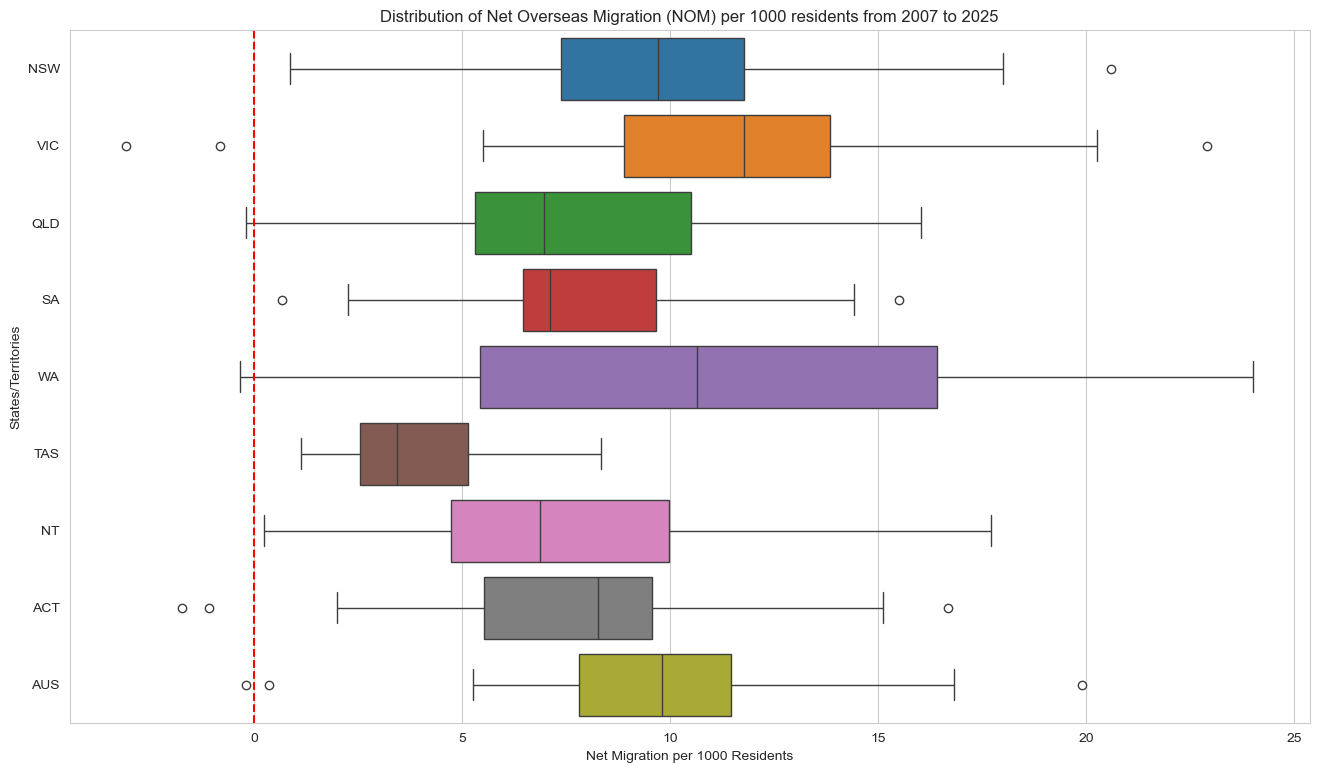

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
fig1, axes1 = plt.subplots(figsize=(16, 9))
sns.boxplot(data=migration_per_capita, orient='h', ax=axes1)
axes1.set_xlabel('Net Migration per 1000 Residents')
axes1.set_title('Distribution of Net Overseas Migration (NOM) per 1000 residents from 2007 to 2025')
axes1.set_ylabel('States/Territories')

# add a reference line at 0% to easily compare migration of each state to the baseline
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

<h3>Takeaways</h3>
<ul class="body-text" style="list-style-type: dot">
<li>Across all states and territories, <strong>net overseas migration (NOM)</strong> to Australia had been overwhelmingly positive</li>
<li>New South Wales, Victoria and Western Australia were leading the race in NOM.</li>
<li>Western Australia showed the largeest variation in its migration rate over the 18 year reference period while Tasmania is relatively consisent.</li>
</ul>

<h3>How do we expect house prices to behave given the trends with migration?</h3>
<ul class="body-text">
<li>Given Australia's <strong>overwhelmingly positive</strong> intake of migrants, we expected demand for housing to significantly increase.</li>
<li>Thus, we expected to see <strong>increases in house prices by significant amounts</strong> across all states, depending on how large their NOM is.</li>
</ul>

<h3>What about outliers?</h3>
<span class="body-text">The code block below shows our steps to calculating the outliers and presenting them.</span>

In [59]:
# calculate the outliers and store them in a dictionary. this will then be converted into a DataFrame
outlier_data = {'Year': [],'State': [],'Migration Outliers': []}
for state in migration_per_capita.columns:
    # get the lower and upper quartiles
    Q1 = migration_per_capita[state].quantile(0.25)
    Q3 = migration_per_capita[state].quantile(0.75)

    # calculate the interquartile range and the upper/lower fences
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    # statistically, we define an outlier as a value that exists outside the range given by the upper and lower fences
    outliers_series = migration_per_capita[state][(migration_per_capita[state] < lower_fence) | (migration_per_capita[state] > upper_fence)]

    # loop through all outliers and add them to our data dictionary
    for i, row in enumerate(outliers_series):
        outlier_data['Year'].append(outliers_series.index[i])
        outlier_data['State'].append(state)
        outlier_data['Migration Outliers'].append(row)

# convert our outlier data into a DataFrame
outliers = pd.DataFrame(outlier_data)
outliers

,Year,State,Migration Outliers
0,2023-01-01,NSW,20.602205
1,2020-01-01,VIC,-3.079344
2,2021-01-01,VIC,-0.818593
3,2023-01-01,VIC,22.899239
4,2021-01-01,SA,0.671252
5,2023-01-01,SA,15.498109
6,2020-01-01,ACT,-1.078887
7,2021-01-01,ACT,-1.723726
8,2023-01-01,ACT,16.675860
9,2020-01-01,AUS,-0.194548


<h3>Outlier analysis</h3>
<span class="body-text">
<ul style="list-style-type: square">
<li>2023 is the only year among the outliers with extremely large increases in net overseas migration <strong>(15-20 migrants per 1000 people)</strong>. This is likely attributed to the <strong>historic high post-pandemic boom in immigration</strong> of students and skilled workers.</li>
<li>Naturally, the unusually large migration rate was concentrated the most in <strong>New South Wales and Victoria</strong>, two states that have historically always seen the highest migration rates in Australia. These two states boasted a net overseas migration rate of <strong>20 and 22 migrants per 1000 people respectively</strong>.</li>
<li><strong>South Australia and the Australian Capital Territory (ACT)</strong> also saw a huge spike in migration in 2023, having experienced rates of <strong>15 and 16 migrants per 1000 people respectively</strong>.</li>
<li>Conversely, there were <strong>also record lows</strong> in migration, in the period of 2020-2021, in <strong>Victoria and the ACT</strong>. Both states experienced a <strong>loss</strong> of migrants with <strong>Victoria going as low as losing 3 migrants per 1000 people</strong>, likely due to the very strict lockdown laws in Victoria, prompting people to move interstate, while in the ACT, workers may have relocated to other states too as remote work became more common during the pandemic.</li>
<li>Surprisingly, <strong>New South Wales (NSW) did not see any decrease in migration</strong>, likely because Sydney is Australia's largest city and economic hub which attracted migrants due to the opportunities present.</li>
</ul>
</span>

<h3>Visualising the relationship between % change in median house prices and net overseas migration</h3>
<h4>We went through the following steps to analyse the relationship between the two variables:</h4>
<ol class="body-text">
<li>Plot a dual-axis time series graph of <strong>% change in median house prices</strong> and <strong>net overseas migration</strong>. This will allow us to see whether spikes or drops in net overseas migration coincide with notable changes in median house prices.</li>
<li><strong>Lag net overseas migration</strong> since house prices are not expected to respond instantly to migration-driven demand pressures and may adjust over time.</li>
<li>Investigate the actual correlation between the two variables using a scatter plot. <strong>Based on theory</strong>, we hypothesise that increases in net overseas migration is correlated with increases in median house prices due to heightened demand for housing.</li>
<li><strong>Quantify</strong> the strength of the linear relationship between house price growth and net migration using Pearson's Correlation Coefficient.</li>
</ol>

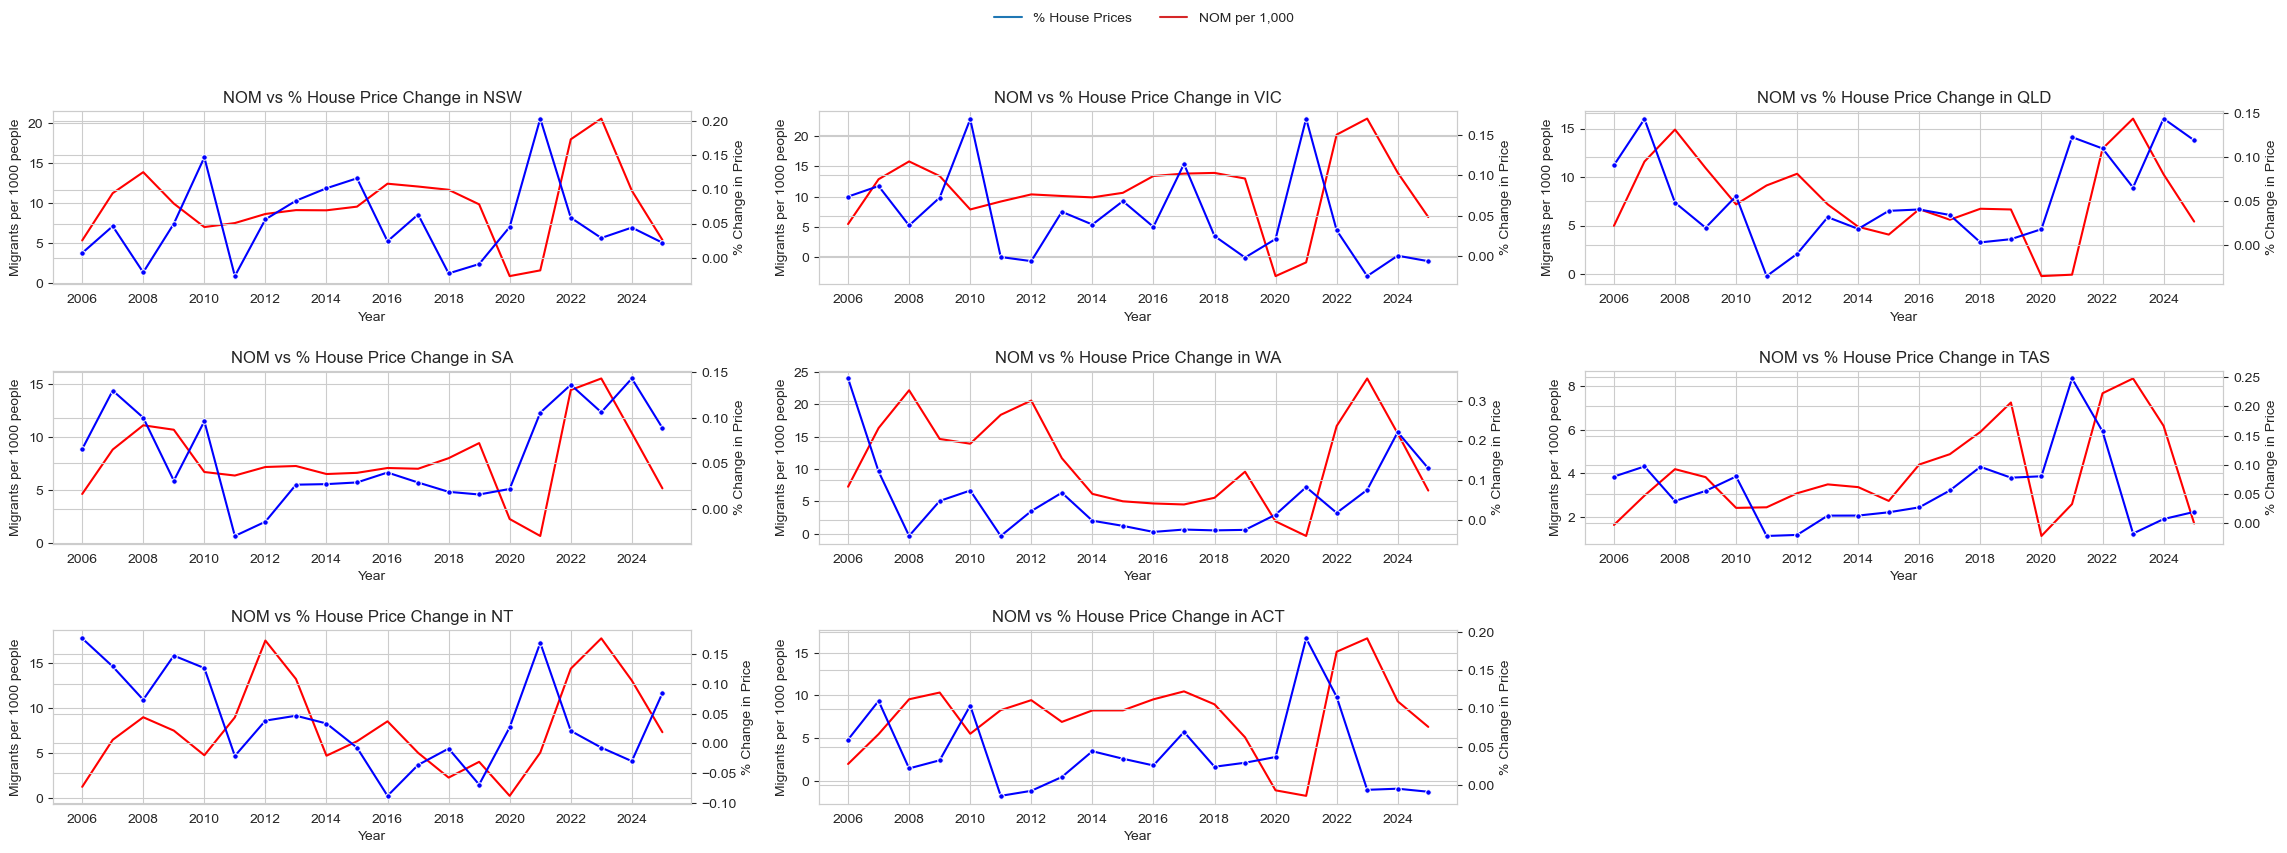

In [60]:
# Step 1: Plot the dual-axis line plot
fig3, axes3 = plt.subplots(nrows=3, ncols=3, figsize=(28, 9))
axes3 = axes3.flatten()
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='tab:blue', label='% House Prices'),
    Line2D([0], [0], color='tab:red', label='NOM per 1,000')
]
fig3.legend(handles=legend_elements,
           loc='upper center',
           ncol=2,
           frameon=False)

for i, state in enumerate(migration_per_capita.columns):
    sns.lineplot(ax=axes3[i], data=migration_per_capita[state], color='red')
    axes3[i].set_title(f'NOM vs % House Price Change in {state}')
    axes3[i].set_ylabel('Migrants per 1000 people')
    axes32 = axes3[i].twinx()
    sns.lineplot(ax=axes32, data=pct_price_changes_by_year[state], color='blue', marker='o', markersize=4)
    axes32.set_ylabel('% Change in Price')
    if i == 8:
        axes32.set_visible(False)

plt.subplots_adjust(hspace=0.5)
axes3[8].set_visible(False)
plt.show()

<h3>Interpretations</h3>
<ul class="body-text" style="list-style-type: square">
<li><strong>Every Australian state and territory</strong>, except Western Australia, saw a <strong>record jump in median house prices in 2022</strong>, likely driven by low interest rates and high housing demand from migration.</li>
<li>In <strong>2020</strong>, net overseas migration per 1,000 people reached <strong>record lows</strong> for most states, except South Australia, ACT, and Western Australia, where migration was lowest in 2021. This was largely due to <strong>Australia’s border closures during the COVID-19 pandemic</strong>.</li>
<li>The post-pandemic surge in net overseas migration in 2022–23 <strong>appears to coincide</strong> with brief rises in median house prices in most states, suggesting <strong>migration-driven demand may have contributed to short-term price growth</strong>.</li>
<li>The NT and ACT were exceptions, possibly reflecting lower housing demand or constrained housing supply.</li>
<li>Net overseas migration per 1,000 people was also high in 2008, driven largely by arrivals from India, New Zealand, and China.</li>
<li>The <strong>magnitude of net overseas migration</strong> was highest in NSW, VIC, and WA. NSW and VIC are Australia's largest states with the highest population densities, making them attractive for immigrants. WA’s smaller population means its migration per 1,000 people is high, even if absolute arrivals were fewer.</li>
</ul>
<h3>Tradeoff</h3>
<ul class="body-text" style="list-style-type: square">
<li>Aggregating housing price data to annual % changes likely smooths out short-term cyclical patterns within the year.</li>
<li>Using quarterly data could reveal these cycles, but we retain annual data to focus on longer-term trends and correlations with net overseas migration.</li>
</ul>
<span class="body-text">We also lagged net overseas migration since housing prices are expected to take time to respond to demand stemming from migration.

The following scatter plot intends to show the strength of the relationship between % change in median house prices and net migration per 1000 residents.</span>

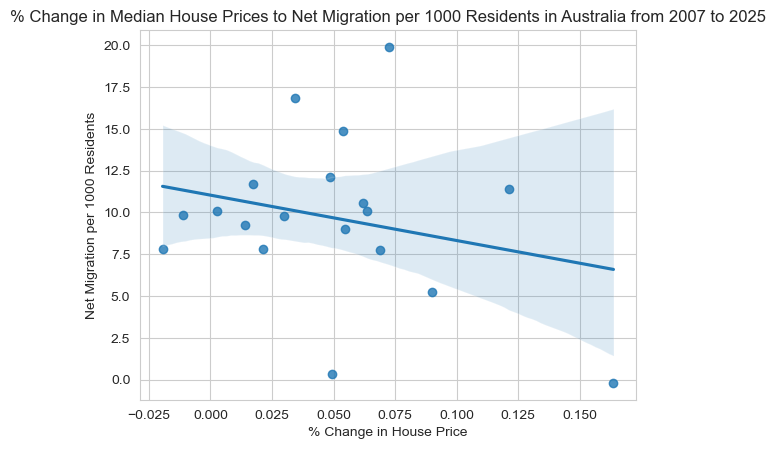

In [61]:
fig4, axes4 = plt.subplots()
sns.regplot(x=pct_price_changes_by_year['AUS'], y=migration_per_capita['AUS'].shift(1))
axes4.set_title('% Change in Median House Prices to Net Migration per 1000 Residents in Australia from 2007 to 2025')
axes4.set_xlabel('% Change in House Price')
axes4.set_ylabel('Net Migration per 1000 Residents')
plt.show()

<h3>Takeaways</h3>
<span class="body-text">Lagged migration was used to reflect the delayed effect of population inflows on housing demand. The bivariate correlation is weakly negative, likely reflecting reverse causality and other omitted factors. This will be explored further in the state-level analysis and when housing supply is introduced.</span>

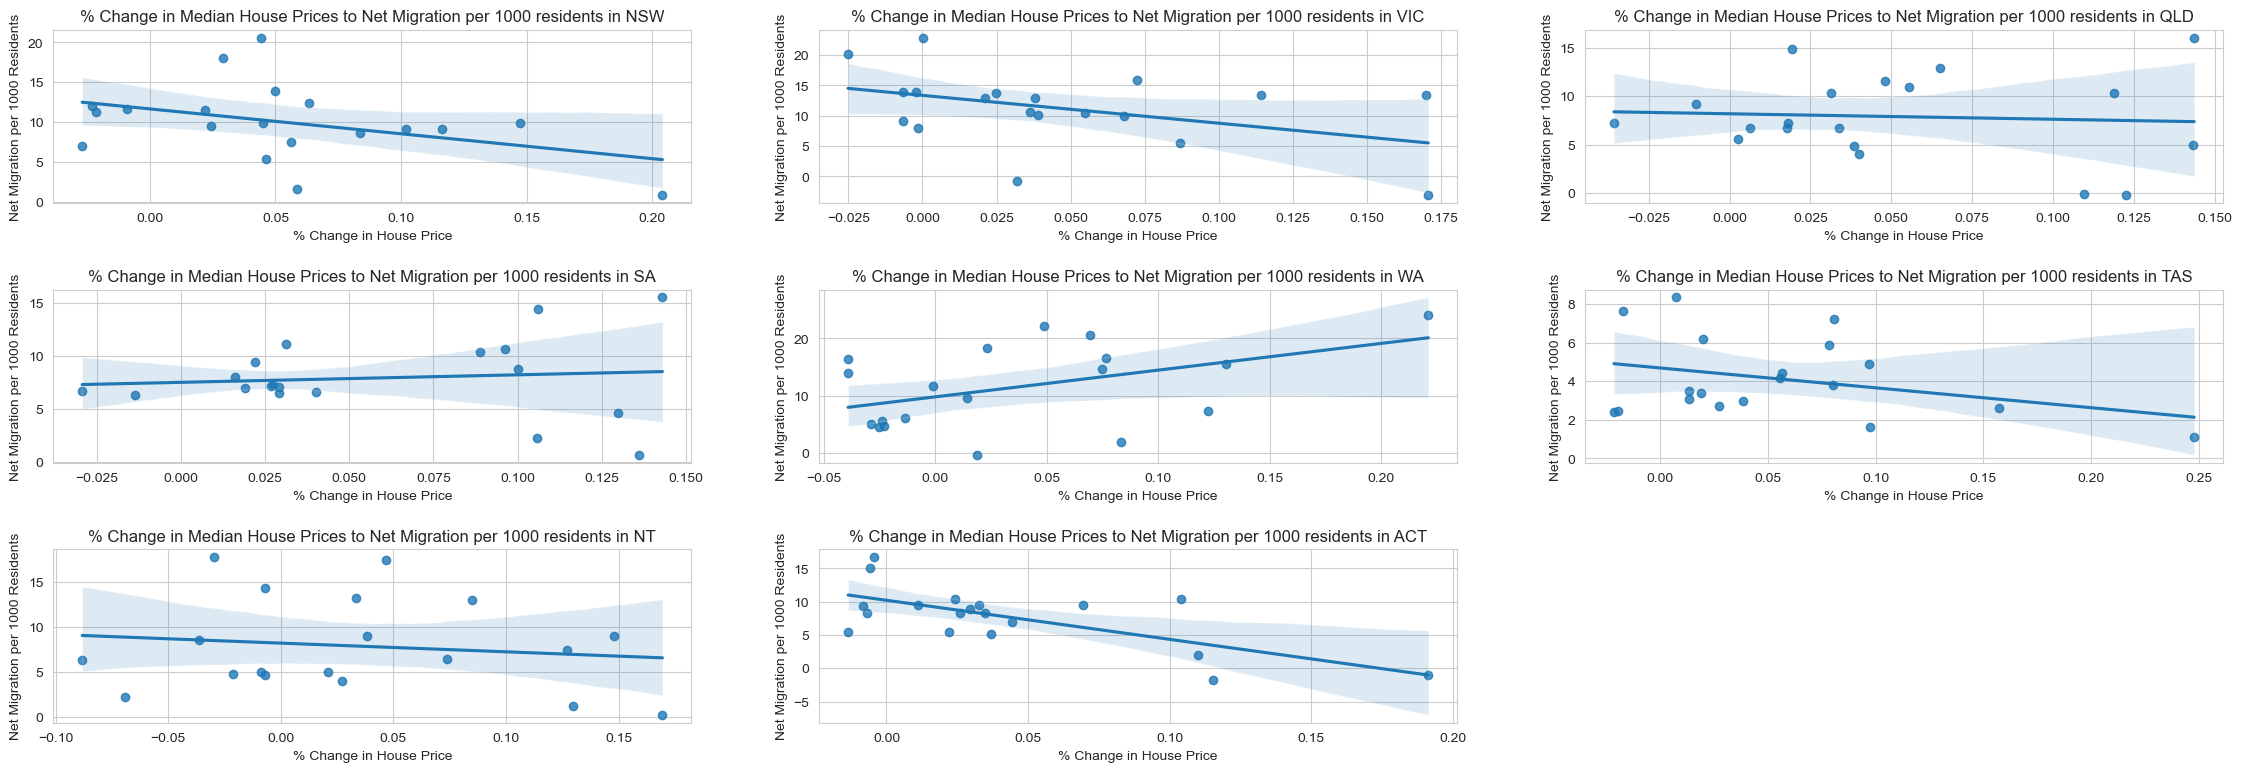

In [62]:
fig5, axes5 = plt.subplots(nrows=3, ncols=3, figsize=(28, 9))
axes5 = axes5.flatten()
for i, state in enumerate(migration_per_capita.columns):
    sns.regplot(x=pct_price_changes_by_year[state], y=migration_per_capita[state].shift(1), ax=axes5[i])
    axes5[i].set_xlabel('% Change in House Price')
    axes5[i].set_ylabel('Net Migration per 1000 Residents')
    axes5[i].set_title(f'% Change in Median House Prices to Net Migration per 1000 residents in {state}')
    if i == 8:
        axes5[i].set_visible(False)
plt.subplots_adjust(hspace=0.5)
plt.show()

<h3>State-level analysis</h3>
<ul class="body-text" style="list-style-type: square">
<li>With the exception of Western Australia, all states possess a weak negative bivariate correlation between the change in house price and net migration rate.</li>
<li>According to theory, there should be a positive trend between net migration rate and % change in median house prices, <strong>all else being equal</strong>.</li>
<li>A likely explanation for our results is that net migration is simply <strong>not the only major factor</strong> to influence changes in house prices, with <strong>interest rates and housing supply</strong> being other major contributors to these changes.</li>
</ul>

<span class="body-text">
It is also worth <strong>quantifying</strong> the strength of the linear relationship between our two variables.
</span>

<span class="body-text">
To do this, we will do the following for each state and the overall national level:
<ol>
<li>Calculate the strength and sign of the linear relationship using <strong>Pearson's Correlation Coefficient.</strong></li>
<li>Perform a <strong>hypothesis test</strong> with the hypotheses outlined in the <strong>Objectives</strong> section.</li>
</ol>
<ul class="body-text">
<li><strong>Null hypothesis (H<sub>0</sub>):</strong> There is no statistically significant linear relationship between net overseas migration rates and changes in median house prices across Australia's states and territories.</li>
<li><strong>Alternative hypothesis (H<sub>1</sub>):</strong> There is a statistically significant linear relationship between net overseas migration rates and changes in median house prices across Australia's states and territories.</li>
</ul>
</span>

In [63]:
from scipy.stats import pearsonr
correlations_dict = {
    'State': [],
    'Correlation': [],
    'p-value': [],
}
for state in migration_per_capita.columns:
    x = migration_per_capita[state].shift(1).dropna()
    y = pct_price_changes_by_year.loc[x.index, state]
    correlation_coefficient, p_value = pearsonr(x, y)
    correlations_dict['State'].append(state)
    correlations_dict['Correlation'].append(correlation_coefficient)
    correlations_dict['p-value'].append(p_value)

correlations = pd.DataFrame(correlations_dict)
correlations.index = correlations.pop('State')
correlations

,Correlation,p-value
State,,
NSW,-0.390475,0.098357
VIC,-0.421991,0.071910
QLD,-0.067797,0.782722
SA,0.103120,0.674413
WA,0.452823,0.051552
TAS,-0.330461,0.167019
NT,-0.136797,0.576545
ACT,-0.683436,0.001256
AUS,-0.251750,0.298469


<h2>Results</h2>
<table class="body-text" style="width: 90%; margin-left: auto; margin-right: auto; border-collapse: collapse; font-size: 20px">
  <tr style="text-align: center">
    <th style="padding: 10px; border: 1px solid #ccc;">State/Level</th>
    <th style="padding: 10px; border: 1px solid #ccc;">Pearson Correlation</th>
    <th style="padding: 10px; border: 1px solid #ccc;">p-value</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc;">Australia (national level)</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$-0.252$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.298$</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc;">New South Wales</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$-0.390$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.098$</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc;">Victoria</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$-0.422$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.072$</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc;">Queensland</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$-0.068$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.783$</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc;">South Australia</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.103$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.674$</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc;">Western Australia</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.453$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.052$</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc;">Tasmania</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$-0.330$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.167$</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc;">Northern Territory</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$-0.137$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.577$</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc;">Australian Capital Territory</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$-0.683$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">$0.001$</td>
  </tr>
</table>

<h3>Conclusions</h3>
<ul class="body-text" style="list-style-type: square">
<li>At the <strong>5% level of significance</strong>, the null hypothesis remained <strong>not rejected</strong> for all states <strong>except</strong> the <strong>Australian Capital Territory (ACT)</strong></li>
<li>For the ACT, $p < 0.01$ implied that at the <strong>1% level of significance</strong>, there was strong statistical evidence to <strong>reject</strong> the null hypothesis that there is no linear correlation. The Pearson Correlation was $-0.683$, indicating a relatively strong negative linear relationship between median house prices and net migration per 1000 residents.</li>
</ul>

<h2>Summary of our findings</h2>
<ul class="body-text" style="list-style-type: square">
<li><h4>Consistency with reality</h4>
<ul style="list-style-type: square">
<li>Our data across all states was generally consistent with the behaviour of house prices and migration over the past 18 years.</li>
<li>The data exhibited expected spikes and drops during notable events such as the COVID-19 pandemic where migration was at record lows in 2020 but began to spike considerably in 2022-2023.</li>
<li><strong>Outliers in migration rates</strong>, both extreme highs and extreme lows, were seen around time period of the COVID-19 pandemic where many states such as New South Wales and Victoria experienced extreme surges in migration after lockdown had ended and record lows (or losses) in net migration during the pandemic lockdown itself.</li>
</ul>
</li>
<li><h4>Correlation findings</h4></li>
<ul class="body-text">
<li>At a <strong>national level</strong>, the correlation between house prices and migration rates was seen to be <strong>weak</strong> as indicated by the p value $p=0.298$ which leads us to not reject the null hypothesis.</li>
<li>The overall correlation between net migration per 1000 residents and % change in median house prices was <strong>weak</strong> across <strong>all states</strong>, as evident by the scatter plots and the p values for each state which imply that there is insufficient evidence to reject the null hypothesis.</li>
<li>However, the <strong>Australian Capital Territory</strong> was an exception where there was strong statistical evidence found to believe there was a linear relationship between net migration and change in house prices in the state. The linear correlation was found to be <strong>negative and relatively strong</strong>, indicated by the Pearson correlation $-0.683$.</li>
</ul>
<li><h4>Limitations of the analysis</h4></li>
<ul class="body-text">
<li><strong>Availability of residential building types:</strong> Data for median house prices were only available for detached dwellings and established houses.</li>
<li><strong>Availability of migration data on a city level:</strong> Having access to migration rates within cities provides more data points with which we can analyse the correlation between migration rates and house price changes.</li>
<li><strong>Lack of a wider reference period:</strong> Having access to migration data that goes back earlier than 2006 (like our housing price data which goes as far back as 1983) would provide more data points to use in our correlation analysis.</li>
</ul>
<li><h4>Potential improvements</h4></li>
<ul class="body-text">
<li><strong>Incorporating other major factors such as interest rates</strong> would provide a clearer picture of the drivers of housing prices in Australia, which would allow the government to make more informed decisions on how to tackle one of nation's biggest issues.</li>
<li><strong>Investigating the possibility</strong> that housing prices and migration rates may follow a <strong>non-linear</strong> relationship and thus, explore whether a different kind of relationship is possible.</li>
<li>Gaining access to migration data spanning a wider reference period would provide more data points for the correlation analysis, making our conclusions more reliable and indicative of how house prices and migration rates behave together.</li>
</ul>
</ul>